# Cardio Bootstrap Results

Run `python -m runnables.run_cardio_bootstrap_evaluation --n-seeds 10 --n-bootstraps 10` before executing this notebook.

If you also want the stored observational and interventional samples for each trained seed, run the experiment with `--store-samples`.


In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tueplots import bundles, figsizes

from datasets.cardio import get_cardio_graph, prepare_cardio_data
from plotting.cardio_formula import choose_formula_targets, get_delta, radar_factory, select_symbolic_formula_payload
from utils.paths import get_experiment_paths

paths = get_experiment_paths('cardio_bootstrap')
summary_path = paths.data / 'cardio_bootstrap_metrics_summary.csv'
training_path = paths.data / 'cardio_bootstrap_training_summary.csv'
formula_metadata_path = paths.data / 'cardio_bootstrap_symbolic_formulas_metadata.csv'
formula_table_path = paths.data / 'cardio_bootstrap_symbolic_formulas.csv'
formula_payload_path = paths.data / 'cardio_bootstrap_symbolic_formulas.pkl'

if not summary_path.exists():
    raise FileNotFoundError(
        f'Missing {summary_path}. Run `python -m runnables.run_cardio_bootstrap_evaluation --n-seeds 10 --n-bootstraps 10` first.'
    )
if not formula_payload_path.exists():
    raise FileNotFoundError(
        f'Missing {formula_payload_path}. Re-run the bootstrap cardio experiment including the KAAM mixed model.'
    )

summary_df = pd.read_csv(summary_path)
training_summary_df = pd.read_csv(training_path) if training_path.exists() else pd.DataFrame()
formula_metadata_df = pd.read_csv(formula_metadata_path) if formula_metadata_path.exists() else pd.DataFrame()
formula_table_df = pd.read_csv(formula_table_path) if formula_table_path.exists() else pd.DataFrame()
with open(formula_payload_path, 'rb') as handle:
    formula_payloads = pickle.load(handle)

prepared = prepare_cardio_data()
graph_cardio = get_cardio_graph()
factual_eval_d = prepared.factual_eval_d
node_info = prepared.node_info

summary_df.head()


,model_name,base_model,variant,metric,mean,median,std,min,max,q025,q975,n
0,anm,anm,Original,dhsic,0.000277,0.000269,0.000084,0.000169,0.000439,0.000169,0.000438,100
1,anm,anm,Original,hsic,16097.856125,15338.578135,2059.955896,13697.016753,21457.858281,13697.016753,21417.706961,100
2,anm,anm,Original,mae,0.379271,0.379372,0.002880,0.375379,0.384453,0.375389,0.384407,100
3,anm,anm,Original,mmd_obs_avg,0.008638,0.008731,0.001064,0.006183,0.011296,0.006767,0.010722,100
4,anm,anm,Original,rf_acc_obs_avg,0.865645,0.864253,0.012095,0.838235,0.898190,0.845023,0.890328,100


In [2]:
metrics_map = {
    'mmd_obs_avg': 'MMD obs',
    'rf_acc_obs_avg': 'RF acc. obs.',
    'hsic': 'HSIC',
    'dhsic': 'dHSIC',
    'mae': 'MAE',
}
models_map = {
    'kan_mixed': 'KAN mixed',
    'kaam_mixed': 'KAAM mixed',
    'kan': 'KAN',
    'kaam': 'KAAM',
    'anm': 'ANM',
    'dbcm': 'DBCM',
    'flow': 'CFlow',
}
metrics_to_plot = ['MMD obs', 'RF acc. obs.', 'HSIC', 'dHSIC', 'MAE']
models_to_plot = ['KAN mixed', 'KAAM mixed', 'ANM', 'DBCM', 'CFlow']
variant_order = ['Original', 'Pruned', 'Symbolic']

df_plot = summary_df.copy()
df_plot = df_plot[df_plot['metric'].isin(metrics_map)].copy()
df_plot['metric'] = df_plot['metric'].map(metrics_map)
df_plot['Model'] = df_plot['base_model'].map(models_map)
df_plot = df_plot[df_plot['Model'].isin(models_to_plot)].copy()

expanded_rows = []
for _, row in df_plot.iterrows():
    if row['base_model'] == 'kaam_mixed':
        expanded_rows.append(row.to_dict())
    else:
        for variant in variant_order:
            row_copy = row.copy()
            row_copy['variant'] = variant
            expanded_rows.append(row_copy.to_dict())

df_plot = pd.DataFrame(expanded_rows)
df_plot['variant'] = pd.Categorical(df_plot['variant'], categories=variant_order, ordered=True)
df_plot = df_plot.sort_values(['metric', 'Model', 'variant']).reset_index(drop=True)
df_plot.head()


,model_name,base_model,variant,metric,mean,median,std,min,max,q025,q975,n,Model
0,anm,anm,Original,HSIC,16097.856125,15338.578135,2059.955896,13697.016753,21457.858281,13697.016753,21417.706961,100,ANM
1,anm,anm,Pruned,HSIC,16097.856125,15338.578135,2059.955896,13697.016753,21457.858281,13697.016753,21417.706961,100,ANM
2,anm,anm,Symbolic,HSIC,16097.856125,15338.578135,2059.955896,13697.016753,21457.858281,13697.016753,21417.706961,100,ANM
3,flow,flow,Original,HSIC,4054.158638,3947.734740,1060.530733,2330.538359,7389.851778,2505.549427,6375.686937,100,CFlow
4,flow,flow,Pruned,HSIC,4054.158638,3947.734740,1060.530733,2330.538359,7389.851778,2505.549427,6375.686937,100,CFlow


/tmp/ipykernel_3185822/1240144705.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


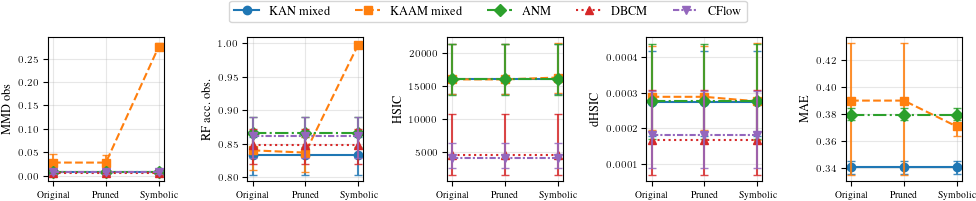

In [3]:
palette = dict(zip(models_to_plot, sns.color_palette('tab10', n_colors=len(models_to_plot))))
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
markers = ['o', 's', 'D', '^', 'v']
style_map = {model: linestyles[i % len(linestyles)] for i, model in enumerate(models_to_plot)}
marker_map = {model: markers[i % len(markers)] for i, model in enumerate(models_to_plot)}
x_positions = np.arange(len(variant_order))

with plt.rc_context({**bundles.neurips2024(ncols=len(metrics_to_plot))}):
    fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(10, 1.9), sharex=True)

    for ax, metric in zip(axs, metrics_to_plot):
        metric_data = df_plot[df_plot['metric'] == metric]
        for model in models_to_plot:
            subset = metric_data[metric_data['Model'] == model].sort_values('variant')
            if subset.empty:
                continue
            y = subset['mean'].to_numpy()
            yerr = np.vstack([
                y - subset['q025'].to_numpy(),
                subset['q975'].to_numpy() - y,
            ])
            ax.plot(
                x_positions,
                y,
                label=model,
                color=palette[model],
                linestyle=style_map[model],
                marker=marker_map[model],
            )
            ax.errorbar(
                x_positions,
                y,
                yerr=yerr,
                fmt='none',
                ecolor=palette[model],
                capsize=3,
                alpha=0.85,
            )

        ax.set_xticks(x_positions, variant_order)
        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=5,
        fontsize='medium',
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(paths.figures / 'cardio_bootstrap_results.pdf', dpi=300, bbox_inches='tight')
    plt.show()


In [4]:
selected_formula_payload = select_symbolic_formula_payload(formula_payloads, rng_seed=2026)
selected_seed = int(selected_formula_payload['seed'])
selected_model_name = selected_formula_payload['model_name']
selected_formulas = selected_formula_payload['formulas']
radar_node, pdp_node = choose_formula_targets(graph_cardio, selected_formulas)
patient_rng = np.random.default_rng(selected_seed)
patient_ids = np.sort(patient_rng.choice(len(factual_eval_d), size=min(2, len(factual_eval_d)), replace=False))
colors = ['tab:red', 'tab:orange']
seed_sample_dir = paths.samples / 'by_seed' / selected_model_name / f'seed_{selected_seed}'
seed_observational_df = pd.read_csv(seed_sample_dir / 'observational.csv') if (seed_sample_dir / 'observational.csv').exists() else pd.DataFrame()
seed_interventional_manifest = pd.read_csv(seed_sample_dir / 'interventional_manifest.csv') if (seed_sample_dir / 'interventional_manifest.csv').exists() else pd.DataFrame()

print(f'Selected symbolic model: {selected_model_name}')
print(f'Selected seed: {selected_seed}')
print(f'Radar target: {radar_node}')
print(f'Secondary PDP target: {pdp_node}')
print(f'Patient ids used in the formula plots: {patient_ids.tolist()}')
display(formula_metadata_df[formula_metadata_df['seed'] == selected_seed].sort_values(['variant', 'model_name']))
display(formula_table_df[formula_table_df['seed'] == selected_seed].sort_values(['node']))


Selected symbolic model: kaam_mixed_symbolic
Selected seed: 8
Radar target: ischemia
Secondary PDP target: systolic
Patient ids used in the formula plots: [721, 1588]


,model_name,base_model,variant,seed,has_formulas,formula_status,n_formulas
16,kaam_mixed_pruned,kaam_mixed,Pruned,8,False,not_symbolic,0
17,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,True,symbolic_extracted,5


,model_name,base_model,variant,seed,node,formula
43,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,bmi,-0.025*age**2 + 0.09*age + 0.02
40,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,diabetes,0.09*age**2 + 0.293*age + 0.061*bmi**2 + 0.201...
42,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,ischemia,0.055*age**2 + 0.173*age + 0.031*bmi**2 + 0.11...
44,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,macv,1.715*diabetes + 4.757*ischemia - 1.964
41,kaam_mixed_symbolic,kaam_mixed,Symbolic,8,systolic,0.359*age + 0.284*bmi + 0.028


In [5]:
if seed_sample_dir.exists():
    print(f'Seed-level sample archive: {seed_sample_dir}')
    display(seed_observational_df.head())
    display(seed_interventional_manifest.head())
else:
    print('Seed-level samples are not available. Re-run the bootstrap experiment with --store-samples to materialize them.')


Seed-level sample archive: /home/almo/CODE/ka_gcm/outputs/cardio_bootstrap/samples/by_seed/kaam_mixed_symbolic/seed_8


,age,bmi,ischemia,diabetes,macv,systolic
0,0.020777,-1.775264,1,1,1,-1.058239
1,0.424661,1.119142,1,1,1,1.047642
2,-0.355814,0.015759,1,1,1,1.490598
3,-2.003991,-0.754066,1,1,1,-0.352107
4,0.259620,0.188630,1,1,1,-0.684875


,node,value,file_name,num_rows
0,age,-3.0,interventional__age__neg3p000.csv,2208
1,age,-2.9,interventional__age__neg2p900.csv,2208
2,age,-2.8,interventional__age__neg2p800.csv,2208
3,age,-2.7,interventional__age__neg2p700.csv,2208
4,age,-2.6,interventional__age__neg2p600.csv,2208


/tmp/ipykernel_3185822/1018820961.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.82, 1])


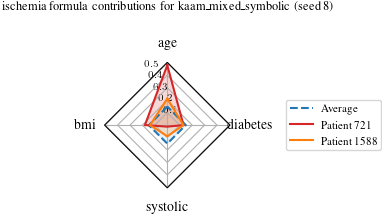

0.055*age**2 + 0.173*age + 0.031*bmi**2 + 0.114*bmi + 0.743*diabetes + 0.046*systolic**2 + 0.155*systolic - 1.871


In [6]:
def contribution_ylabel(node):
    if node_info[node]['type'] == 'discrete':
        return rf'$\Delta$ logit(P({node}))'
    return f'Contribution to {node}'

x_cols_radar = list(graph_cardio.predecessors(radar_node))
formula_radar = selected_formulas[radar_node]
delta_formula_radar, delta_frames_radar = get_delta(factual_eval_d[x_cols_radar], formula_radar)
delta_radar = delta_frames_radar[0].iloc[:, :-1]
theta = radar_factory(len(delta_radar.columns), frame='polygon')
avg_profile = np.repeat(delta_radar.mean(axis=0).sum(), len(delta_radar.columns))
avg_matrix = np.repeat(delta_radar.mean(axis=0).to_numpy()[None, :], len(delta_radar.columns), axis=0)

with plt.rc_context({**bundles.iclr2024()}):
    fig, ax = plt.subplots(subplot_kw=dict(projection='radar'), figsize=(5.4, 2.4))
    ax.plot(theta, avg_profile, label='Average', color='tab:blue', linestyle='--')
    ax.fill(theta, avg_profile, alpha=0.10, color='tab:blue')

    for color, patient_id in zip(colors, patient_ids):
        patient_matrix = avg_matrix.copy()
        np.fill_diagonal(patient_matrix, delta_radar.iloc[patient_id].to_numpy())
        patient_profile = patient_matrix.sum(axis=1)
        ax.plot(theta, patient_profile, label=f'Patient {patient_id}', color=color)
        ax.fill(theta, patient_profile, alpha=0.18, color=color)

    ax.set_varlabels(delta_radar.columns, fontsize=10)
    ax.legend(loc='center right', bbox_to_anchor=(2.25, 0.5), ncol=1, fontsize=8)
    ax.set_title(f'{radar_node} formula contributions for {selected_model_name} (seed {selected_seed})', pad=20)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(
        paths.figures / f'cardio_bootstrap_{selected_model_name}_seed_{selected_seed}_{radar_node}_radar.pdf',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()

print(delta_formula_radar)


/tmp/ipykernel_3185822/4245153540.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


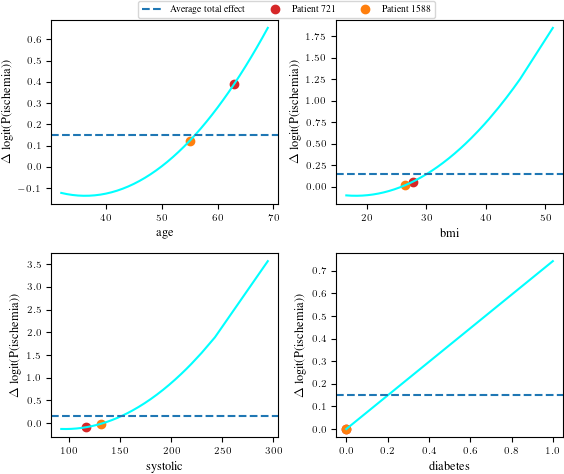

In [7]:
x_cols_pdp = list(graph_cardio.predecessors(radar_node))
n_panels = len(delta_radar.columns)
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))

with plt.rc_context({**bundles.iclr2024(), **figsizes.iclr2024(ncols=2, nrows=max(1, n_rows))}):
    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5.8, 2.4 * n_rows), squeeze=False)

    for panel_index, variable in enumerate(delta_radar.columns):
        row, col = divmod(panel_index, n_cols)
        ax = axs[row, col]
        sorted_idx = np.argsort(factual_eval_d[variable].to_numpy())
        x_values = factual_eval_d[variable].to_numpy()[sorted_idx]
        if node_info[variable]['type'] == 'continuous':
            x_values = x_values * node_info[variable]['std'] + node_info[variable]['mean']
        ax.plot(x_values, delta_radar[variable].to_numpy()[sorted_idx], color='cyan')
        ax.axhline(y=delta_radar.mean(axis=0).sum(), color='tab:blue', linestyle='--', label='Average total effect')
        ax.set_xlabel(variable)
        ax.set_ylabel(contribution_ylabel(radar_node))

        for color, patient_id in zip(colors, patient_ids):
            x_point = factual_eval_d[variable].iloc[patient_id]
            if node_info[variable]['type'] == 'continuous':
                x_point = x_point * node_info[variable]['std'] + node_info[variable]['mean']
            ax.scatter(x_point, delta_radar[variable].iloc[patient_id], color=color, label=f'Patient {patient_id}')

    for panel_index in range(n_panels, n_rows * n_cols):
        row, col = divmod(panel_index, n_cols)
        axs[row, col].axis('off')

    handles, labels = axs[0, 0].get_legend_handles_labels()
    for ax in axs.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
    plt.tight_layout()
    plt.savefig(
        paths.figures / f'cardio_bootstrap_{selected_model_name}_seed_{selected_seed}_{radar_node}_pdp.pdf',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()


/tmp/ipykernel_3185822/2253192900.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


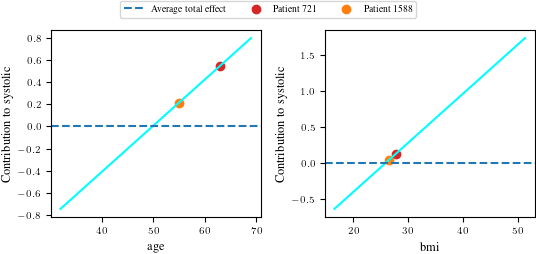

0.359*age + 0.284*bmi + 0.028


In [8]:
formula_pdp = selected_formulas[pdp_node]
x_cols_secondary = list(graph_cardio.predecessors(pdp_node))
delta_formula_pdp, delta_frames_pdp = get_delta(factual_eval_d[x_cols_secondary], formula_pdp)
delta_pdp = delta_frames_pdp[0].iloc[:, :-1]
secondary_panels = len(delta_pdp.columns)

with plt.rc_context({**bundles.iclr2024(), **figsizes.iclr2024(ncols=max(1, secondary_panels), nrows=1)}):
    fig, axs = plt.subplots(nrows=1, ncols=secondary_panels, figsize=(max(4.0, 2.8 * secondary_panels), 2.5), squeeze=False)

    for panel_index, variable in enumerate(delta_pdp.columns):
        ax = axs[0, panel_index]
        sorted_idx = np.argsort(factual_eval_d[variable].to_numpy())
        x_values = factual_eval_d[variable].to_numpy()[sorted_idx]
        if node_info[variable]['type'] == 'continuous':
            x_values = x_values * node_info[variable]['std'] + node_info[variable]['mean']
        ax.plot(x_values, delta_pdp[variable].to_numpy()[sorted_idx], color='cyan')
        ax.axhline(y=delta_pdp.mean(axis=0).sum(), color='tab:blue', linestyle='--', label='Average total effect')
        ax.set_xlabel(variable)
        ax.set_ylabel(contribution_ylabel(pdp_node))

        for color, patient_id in zip(colors, patient_ids):
            x_point = factual_eval_d[variable].iloc[patient_id]
            if node_info[variable]['type'] == 'continuous':
                x_point = x_point * node_info[variable]['std'] + node_info[variable]['mean']
            ax.scatter(x_point, delta_pdp[variable].iloc[patient_id], color=color, label=f'Patient {patient_id}')

    handles, labels = axs[0, 0].get_legend_handles_labels()
    for ax in axs.flat:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=True)
    plt.tight_layout()
    plt.savefig(
        paths.figures / f'cardio_bootstrap_{selected_model_name}_seed_{selected_seed}_{pdp_node}_formula.pdf',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()

print(delta_formula_pdp)


In [9]:
training_summary_df.sort_values('model_name') if not training_summary_df.empty else training_summary_df


,model_name,base_model,variant,mean,median,std,min,max,q025,q975,n
0,anm,anm,Original,0.025809,0.024342,0.018183,0.007179,0.061642,0.007570,0.057666,10
1,dbcm,dbcm,Original,30.006350,34.110143,11.456542,9.991205,41.590147,11.126602,41.275668,10
2,flow,flow,Original,40.833200,47.402933,12.758820,23.589099,56.289034,23.608044,55.967153,10
3,kaam,kaam,Original,37.992733,39.794067,3.304116,33.302083,41.111431,33.321889,41.095976,10
4,kaam_mixed,kaam_mixed,Original,148.529110,141.685884,46.650908,71.515199,219.879658,74.681784,214.483699,10
5,kaam_mixed_pruned,kaam_mixed,Pruned,0.088235,0.057248,0.071880,0.026149,0.254263,0.027487,0.229345,10
6,kaam_mixed_symbolic,kaam_mixed,Symbolic,0.082840,0.087526,0.032207,0.040703,0.136541,0.041863,0.133935,10
7,kan,kan,Original,5.961176,5.610780,0.570867,5.447568,6.794246,5.453415,6.781271,10
8,kan_mixed,kan_mixed,Original,568.368248,573.665818,75.528925,428.254933,676.609190,438.640270,675.546501,10
